____
# Without and with AVISO background

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance,
    compute_variance_groupby,
    plot_error,
)
from swot import browse_swot_2km

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt = 3
distance_to_coast_max = 20e3
alti_product_key = "swot2km"
drifter_preprocess = ""
drifter_preprocess_param = ""
max_ggd = 1e-4
from diagnosis import define_coloc_source

colocs_sources = define_coloc_source(
    "12h", drifter_preprocess, drifter_preprocess_param
)

________
# Visualization

In [115]:
cycle = 500
pass_=3
ctoff=80e3

method = 'diff_only'
dfs = browse_swot_2km().reset_index()
df = dfs[dfs.pass_number == pass_]
ds_swot = df.set_index("cycle_number").to_xarray().persist()
ds_swot = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}.nc"
        ).sel(cycle_number = 500)

ds4 = xr.open_dataset('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/L4_sealevel/L4_withnadirswot.nc'
                      ).sel(time = ds_swot.time.mean(), method='nearest')

method='gaussian_aviso'
dss_ga = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
        ).sel(cycle_number = 500)
method='gaussian_nb'
dss_gs = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
        ).sel(cycle_number = 500)

In [116]:
ds4

<xarray.Dataset> Size: 87kB
Dimensions:       (latitude: 64, longitude: 56)
Coordinates:
    time          datetime64[ns] 8B 2023-04-24
  * latitude      (latitude) float32 256B 36.06 36.19 36.31 ... 43.81 43.94
  * longitude     (longitude) float32 224B 0.0625 0.1875 0.3125 ... 6.812 6.938
    cycle_number  int64 8B 500
Data variables:
    adt           (latitude, longitude) float64 29kB ...
    ugos          (latitude, longitude) float64 29kB ...
    vgos          (latitude, longitude) float64 29kB ...
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_start:             2022-12-31T12:00:00Z
    platform:                        Cryosat-2 New Orbit, Sentinel-3B, Altika...

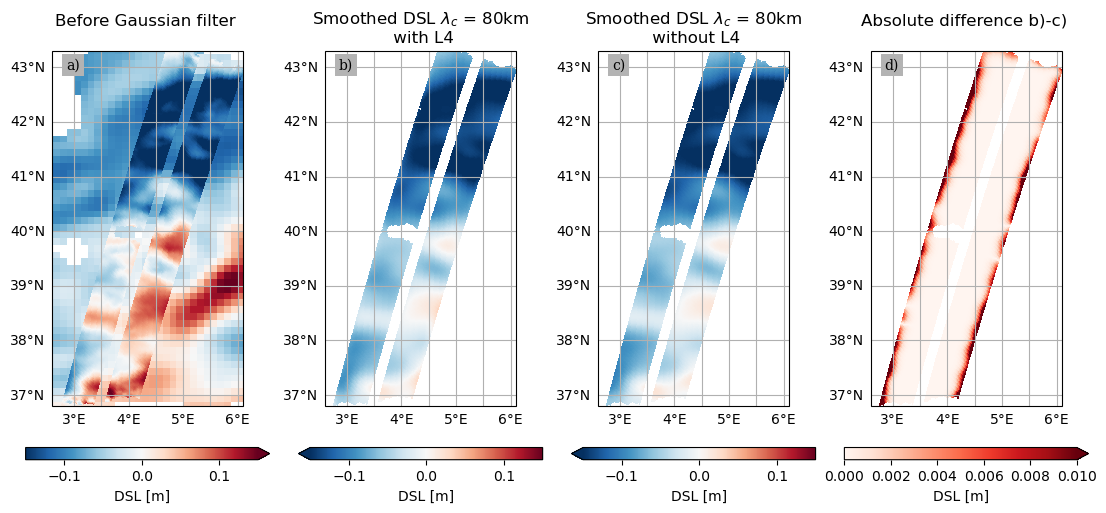

In [155]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

kwargs = dict(
    vmin=-0.15, vmax=0.15, cmap="RdBu_r", cbar_kwargs={"location": "bottom", "pad": 0.05,"label":"DSL [m]"}, 
) 
crs = ccrs.PlateCarree()
bbox = [2.6, 6.1, 36.8, 43.3]

fig, axs = plt.subplots(
    1,
    4,
    figsize=(11, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    layout="constrained",
    sharey=True,
)
axs = axs.flatten()
ax=axs[0]
ds4.adt.plot(x="longitude", y="latitude", transform=crs, ax=ax, **kwargs)
ds_swot.etaf.plot(x="longitude", y="latitude", transform=crs, ax=ax,vmin=-0.15, vmax=0.05, cmap="RdBu_r",add_colorbar=False)
ax.set_title("Before Gaussian filter \n")


ax=axs[1]
dss_ga.filtered_etaf.plot(x="longitude", y="latitude", transform=crs, ax=ax, **kwargs)
ax.set_title(rf"Smoothed DSL $\lambda_c$ = {int(ctoff/1000)}km" + "\n with L4")

ax=axs[2]
a = dss_gs.filtered_etaf.plot(x="longitude", y="latitude", transform=crs, ax=ax, **kwargs)
ax.set_title(rf"Smoothed DSL $\lambda_c$ = {int(ctoff/1000)}km" + "\n without L4")

ax=axs[3]
kwargs = dict(
    vmin=0, vmax=0.01, cmap="Reds", cbar_kwargs={"location": "bottom","label":"DSL [m]"}) 
a= abs(dss_ga.filtered_etaf - dss_gs.filtered_etaf).plot(x="longitude", y="latitude", transform=crs, ax=ax, **kwargs)
ax.set_title(f"Absolute difference b)-c) \n")


for ax in axs :
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_extent(bbox)

i = 0
for l in ["a", "b", "c", "d",]:
    put_fig_letter(fig, axs[i], l)
    i += 1

_______
# Gaussian

In [4]:
cutoff = sorted(list(np.arange(10e3,51e3, 10e3))+list(np.arange(50e3, 301e3, 30e3)))
cutoff

[10000.0,
 20000.0,
 30000.0,
 40000.0,
 50000.0,
 50000.0,
 80000.0,
 110000.0,
 140000.0,
 170000.0,
 200000.0,
 230000.0,
 260000.0,
 290000.0]

In [8]:
# GAUSSIAN
#cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))
#cutoff = list(np.arange(5e3,31e3, 5e3))+list(np.arange(40e3, 301e3, 20e3))
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="gaussian_nb",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(ct))) for ct in cutoff
]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth="15"))
comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(ct))) for ct in cutoff
]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

# Closure figs
dsg = compute_variance(DSG, compute_error="centrallimit") / U2

DSG = DSG.rename({"id_comb": "cutoff"})
DSG["cutoff"] = DSG.cutoff / 1000
DSG["cutoff"] = DSG["cutoff"].assign_attrs(
    {"long_name": "Gaussian filter cutoff", "units": "km"}
)
dsg = dsg.rename({"id_comb": "cutoff"})
dsg["cutoff"] = dsg.cutoff / 1000
dsg["cutoff"] = dsg["cutoff"].assign_attrs(
    {"long_name": "Gaussian filter cutoff", "units": "km"}
)

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_10000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_20000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_30000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_40000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_50000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_50000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_80000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_110000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_140000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_nb_170000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2

In [9]:
dsg.to_netcdf(
    os.path.join(
        zarr_dir, "diag_files", f"gaussian_nb{colocs_sources}_filtered_nospotter.nc"
    )
)

In [7]:
dsg.to_netcdf(
    os.path.join(
        zarr_dir,
        "diag_files",
        f"gaussian_nb_{colocs_sources}_calibrated_nospotter.nc",
    )
)

## If already computed

In [57]:
xlim =120
dsgf = xr.open_dataset(
    os.path.join(
        zarr_dir, "diag_files", f"gaussian_nb{colocs_sources}_filtered_nospotter.nc"
    )
).sel(cutoff=slice(20,xlim))
dsgc = xr.open_dataset(
    os.path.join(
        zarr_dir,
        "diag_files",
        f"gaussian_nb_{colocs_sources}_calibrated_nospotter.nc",
    )
).sel(cutoff=slice(20,xlim))


dsgf_ = xr.open_dataset(
    os.path.join(
        zarr_dir, "diag_files", f"gaussian_aviso_{colocs_sources}_filtered_nospotter.nc"
    )
).sel(cutoff=slice(20,xlim))
dsgc_ = xr.open_dataset(
    os.path.join(
        zarr_dir,
        "diag_files",
        f"gaussian_aviso_{colocs_sources}_calibrated_nospotter.nc",
    )
).sel(cutoff=slice(20,xlim))

In [58]:
# No filter point

# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="xarray_diff",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)
comb_list = [base_dic, update_dict(base_dic, {"ggd_var": "etac"})]
ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", ["filtered", "calibrated"])
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth="15")) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", ["filtered", "calibrated"])
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSH = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)


# Closure figs
dsh = compute_variance(DSH, compute_error="centrallimit") / U2


KeyboardInterrupt



In [59]:
dsh["cutoff"] = xr.DataArray([0], dims="cutoff")
dsh = dsh.set_coords("cutoff")

In [60]:
dsgc = xr.concat([dsh.sel(id_comb="calibrated"), dsgc], dim="cutoff")
dsgf = xr.concat([dsh.sel(id_comb="filtered"), dsgf], dim="cutoff")

## L4

In [14]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [
    base_dic,
    update_dict(base_dic, {"alti_product_key": "L4_noswot_regional"}),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_global"}),
    update_dict(base_dic, {"alti_product_key": "L4_withnadirswot"}),
]

l = ["L3-SWOT 2km", "L4_noswot_regional", "L4_noswot_global", "L4_withnadirswot"]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth="15")) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

# Closure figs
ds4 = compute_variance(DS4, compute_error="centrallimit") / U2

DS4 = DS4.rename({"id_comb": "altiprod"})
DS4["altiprod"] = DS4["altiprod"].assign_attrs({"long_name": "Altimetric products"})

ds4 = ds4.rename({"id_comb": "altiprod"})
ds4["altiprod"] = ds4["altiprod"].assign_attrs({"long_name": "Altimetric products"})

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio15
only 'from

In [39]:
DS4.latitude.mean()

<xarray.DataArray 'latitude' ()> Size: 8B
array(40.41416198)

In [15]:
DS4["altiprod"] = ["L3-2km", "L4-regional", "L4-global", "L4-SWOT-nadir"]
ds4 = compute_variance(DS4) / U2

# Diagnoses

In [52]:
# Theoritical estimation from chelton 2024 (eq 3b chelton 2022)
def theoritical_chelton(cutoff, sigmassh, cor=3.1e-3): #PAS pour les bonnes footprints
    # eq 3b chelton 2022 + estimation correlation Chelton2024
    g = 9.81
    return 2 * g**2 * (1 - cor) * sigmassh**2 / (cutoff**2)


def fit_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3-5 Chelton 2024
    g = 9.81
    f37 = 2 * 2 * np.pi / 86164.1 * np.sin(37 * np.pi / 180)
    alphauv = 13.86
    return sigmassh*1e2 / 0.4 * alphauv / (cutoff**2)# *(f37**2)


from scipy.optimize import curve_fit

# Exp fit for balanced contributions
def exp_fit(cutoff, a, b):
    return a * np.exp(-cutoff / (b*2*np.pi))


cutoff = xr.DataArray(data=np.arange(10, 200), dims=["cutoff"], name="cutoff")
b_exp_popt, b_pcov = curve_fit(exp_fit, dsgc.sel(cutoff=slice(10, 200)).cutoff, dsgc.sel(cutoff=slice(10, 200)).B_ggd)
b_exp_fit = xr.DataArray(exp_fit(cutoff, *b_exp_popt), coords={"cutoff": cutoff})
b_exp_popt[1] = b_exp_popt[1]*2*np.pi

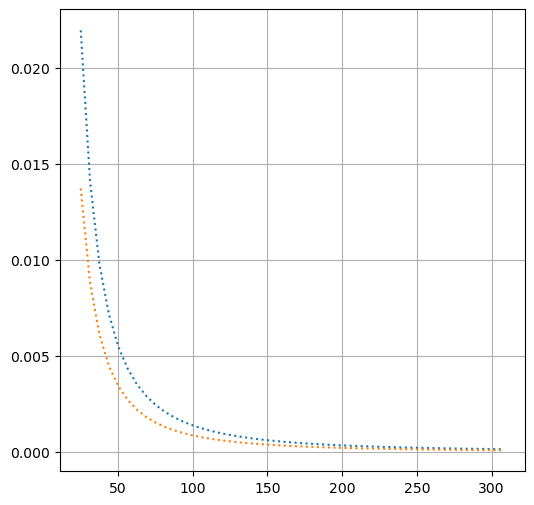

In [53]:
cutoff_ = np.arange(4, 50)*np.pi*2
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(
    cutoff_,
    fit_chelton(cutoff_, 0.4e-2),
    ls=":",
    label="Chelton prediction \n" r"$\sigma_{SSH}$=0.4cm",
)

ax.plot(
    cutoff_,
    fit_chelton(cutoff_, 0.25e-2),
    ls=":",
    label="Chelton prediction \n" r"$\sigma_{SSH}$=0.4cm",
)
ax.grid()

In [54]:
b_exp_fit

<xarray.DataArray 'cutoff' (cutoff: 190)> Size: 2kB
array([1.98703025, 1.97055131, 1.95420904, 1.93800229, 1.92192996,
       1.90599092, 1.89018406, 1.87450829, 1.85896253, 1.84354569,
       1.8282567 , 1.81309452, 1.79805807, 1.78314633, 1.76835825,
       1.75369282, 1.739149  , 1.72472581, 1.71042223, 1.69623727,
       1.68216995, 1.6682193 , 1.65438434, 1.64066412, 1.62705768,
       1.61356409, 1.6001824 , 1.58691169, 1.57375103, 1.56069952,
       1.54775625, 1.53492033, 1.52219085, 1.50956694, 1.49704773,
       1.48463234, 1.47231991, 1.4601096 , 1.44800054, 1.43599191,
       1.42408287, 1.4122726 , 1.40056027, 1.38894508, 1.37742621,
       1.36600287, 1.35467427, 1.34343962, 1.33229814, 1.32124906,
       1.31029161, 1.29942504, 1.28864858, 1.2779615 , 1.26736304,
       1.25685249, 1.2464291 , 1.23609215, 1.22584093, 1.21567472,
       1.20559283, 1.19559455, 1.18567919, 1.17584605, 1.16609447,
       1.15642376, 1.14683325, 1.13732227, 1.12789018, 1.1185363 ,
       1.10926   , 1.10006063, 1.09093756, 1.08189014, 1.07291775,
       1.06401978, 1.0551956 , 1.0464446 , 1.03776617, 1.02915972,
       1.02062464, 1.01216035, 1.00376625, 0.99544177, 0.98718632,
       0.97899934, 0.97088025, 0.9628285 , 0.95484352, 0.94692477,
       0.93907169, 0.93128373, 0.92356036, 0.91590105, 0.90830525,
       0.90077245, 0.89330212, 0.88589374, 0.8785468 , 0.8712608 ,
       0.86403521, 0.85686955, 0.84976332, 0.84271602, 0.83572717,
       0.82879628, 0.82192286, 0.81510645, 0.80834657, 0.80164275,
       0.79499453, 0.78840144, 0.78186303, 0.77537885, 0.76894844,
       0.76257135, 0.75624716, 0.74997541, 0.74375568, 0.73758753,
       0.73147053, 0.72540427, 0.71938831, 0.71342224, 0.70750565,
       0.70163813, 0.69581927, 0.69004867, 0.68432592, 0.67865064,
       0.67302242, 0.66744088, 0.66190562, 0.65641628, 0.65097245,
       0.64557378, 0.64021987, 0.63491037, 0.6296449 , 0.6244231 ,
       0.6192446 , 0.61410905, 0.60901609, 0.60396537, 0.59895653,
       0.59398924, 0.58906314, 0.58417789, 0.57933316, 0.5745286 ,
       0.56976389, 0.5650387 , 0.56035269, 0.55570555, 0.55109695,
       0.54652656, 0.54199408, 0.53749919, 0.53304157, 0.52862093,
       0.52423694, 0.51988931, 0.51557774, 0.51130193, 0.50706157,
       0.50285639, 0.49868607, 0.49455034, 0.49044892, 0.4863815 ,
       0.48234782, 0.47834759, 0.47438053, 0.47044638, 0.46654485,
       0.46267567, 0.45883859, 0.45503333, 0.45125962, 0.44751721,
       0.44380584, 0.44012525, 0.43647518, 0.43285538, 0.42926561,
       0.4257056 , 0.42217512, 0.41867391, 0.41520175, 0.41175838])
Coordinates:
  * cutoff   (cutoff) int64 2kB 10 11 12 13 14 15 16 ... 194 195 196 197 198 199

# Gaussian
## Observed

/dev/shm/pbs.5255858.datarmor0/ipykernel_46839/1842115142.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.5255858.datarmor0/ipykernel_46839/1842115142.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


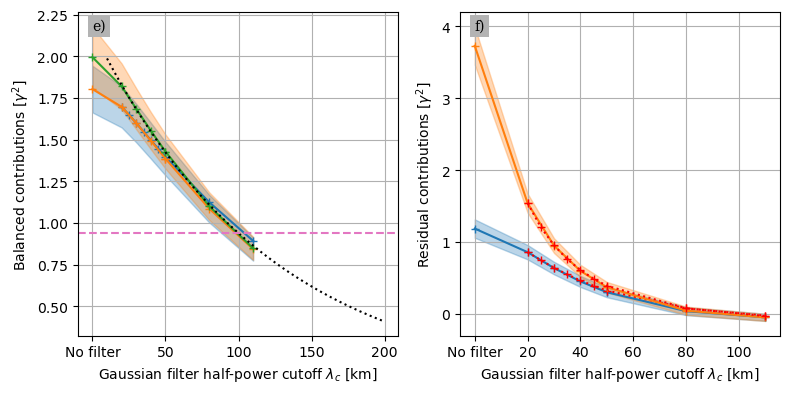

In [61]:
xlim = 80
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4))

ax = axs[0]
dsgf_.B_ggd.plot(ax=ax, label="L3-2km filtered", marker="+")
dsgf.B_ggd.plot(ax=ax, label="L3-2km filtered", marker="+")
plot_error(dsgf, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc.B_ggd.plot(ax=ax, label="L3-2km calibrated", marker="+")
plot_error(dsgc, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)
b_exp_fit.plot(
    ax=ax,
    ls=":",
    color="k",
    label=rf"{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})",
)
ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
put_fig_letter(fig, ax, "e")
ax.set_ylabel(r"Balanced contributions [$\gamma^2$]")
#ax.set_ylim(0.3, 2.4)

ax = axs[1]
dsgf.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km filtered",
)
dsgf_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km filtered",
    ls=':',
    c='r'
)
plot_error(dsgf, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km calibrated",
)
dsgc_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km calibrated",
    ls=':',
    c='r',
)
plot_error(dsgc, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)



put_fig_letter(fig, ax, "f")

ax.set_ylabel(r"Residual contributions [$\gamma^2$]")
#ax.set_ylim(-0.1, 4.5)

fig.tight_layout()

for ax in axs:
    xticks = ax.get_xticks().tolist()
    a = [int(a_) for a_ in xticks]
    a[1] = "No filter"
    ax.set_xticklabels(a)
    ax.set_xlabel(r"Gaussian filter half-power cutoff $\lambda_c$ [km]")
    ax.grid()
    # ax.legend()
    ax.set_title("")


In [46]:
dsgf.sel(cutoff = 20).E_ggd.compute()

<xarray.DataArray 'E_ggd' ()> Size: 8B
array(0.85804794)
Coordinates:
    cutoff   float64 8B 20.0

In [47]:
dsgf_.sel(cutoff = 20).E_ggd.compute()

<xarray.DataArray 'E_ggd' ()> Size: 8B
array(0.85856481)
Coordinates:
    cutoff   float64 8B 20.0

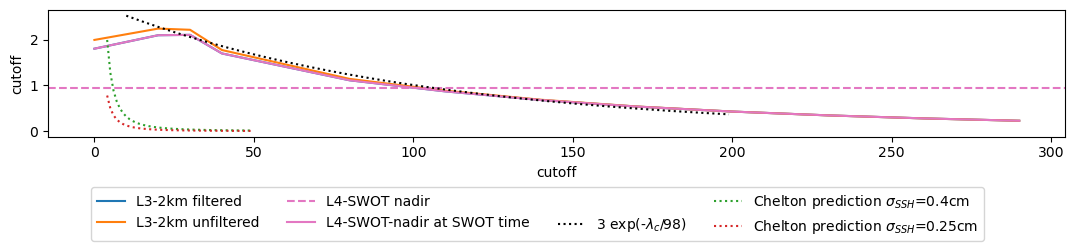

In [45]:
fig, ax = plt.subplots(1, 1, frameon=False, figsize=(11, 2.5))
dsgf.B_ggd.plot(ax=ax, label="L3-2km filtered")
dsgc.B_ggd.plot(ax=ax, label="L3-2km unfiltered")
ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
dsgf.B_ggd.plot(ax=ax, label="L4-SWOT-nadir at SWOT time", color="tab:pink")
dsgc.B_ggd.plot(ax=ax, label=" ", ls="")
b_exp_fit.plot(
    ax=ax,
    ls=":",
    color="k",
    label=rf"{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})",
)
ax.plot(
    np.arange(4, 50),
    theoritical_chelton(np.arange(4, 50) * 1e3, 0.4e-2) / U2,
    ls=":",
    label="Chelton prediction $\sigma_{SSH}$=0.4cm",
    color="tab:green",
)
# ax.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')
ax.plot(
    np.arange(4, 50),
    theoritical_chelton(np.arange(4, 50) * 1e3, 0.25e-2) / U2,
    ls=":",
    label="Chelton prediction $\sigma_{SSH}$=0.25cm",
    color="tab:red",
)

fig.legend(ncol=4, loc="lower center")


fig.tight_layout(rect=[0, 0.2, 1, 1])